In [ ]:
!pip install scorecardpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import lightgbm as lgb

# Credit scoring specific
import scorecardpy as sc

# Utilities
import os
import gc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported")

✓ All libraries imported


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/credit-risk-modeling/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/credit-risk-modeling'
DATA_FILE = f'{DRIVE_PATH}/accepted_2007_to_2018Q4.csv.gz'

assert os.path.exists(DATA_FILE), f"Data file not found at: {DATA_FILE}"
print(f"✓ Data file found")
print(f"  Size: {os.path.getsize(DATA_FILE) / 1024**2:.1f} MB")

✓ Data file found
  Size: 374.4 MB


In [ ]:
%%time
df = pd.read_csv(DATA_FILE,
                 compression='gzip',
                 low_memory=False)

print(f"\n✓ Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


✓ Loaded 2,260,701 rows × 151 columns
  Memory usage: 5992.3 MB
CPU times: user 1min 37s, sys: 9.55 s, total: 1min 47s
Wall time: 1min 50s


In [ ]:

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

print(f"✓ Converted issue_d to datetime")
print(f"  Date range: {df['issue_d'].min()} → {df['issue_d'].max()}")
print(f"  Missing: {df['issue_d'].isna().sum():,} ({df['issue_d'].isna().mean()*100:.2f}%)")

✓ Converted issue_d to datetime
  Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00
  Missing: 33 (0.00%)


In [ ]:
print("=" * 60)
print("BASIC INFO")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Date range: {df['issue_d'].min()} → {df['issue_d'].max()}")
print(f"\nFirst 3 rows:")
df.head(3)

BASIC INFO
Shape: (2260701, 151)
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

First 3 rows:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0000,3600.0000,3600.0000,36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,55000.0000,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,2765.0000,29.7000,13.0000,w,0.0000,0.0000,4421.7239,4421.7200,3600.0000,821.7200,0.0000,0.0000,0.0000,Jan-2019,122.6700,NaN,Mar-2019,564.0000,560.0000,0.0000,30.0000,1.0000,Individual,NaN,NaN,NaN,0.0000,722.0000,144904.0000,2.0000,2.0000,0.0000,1.0000,21.0000,4981.0000,36.0000,3.0000,3.0000,722.0000,34.0000,9300.0000,3.0000,1.0000,4.0000,4.0000,20701.0000,1506.0000,37.2000,0.0000,0.0000,148.0000,128.0000,3.0000,3.0000,1.0000,4.0000,69.0000,4.0000,69.0000,2.0000,2.0000,4.0000,2.0000,5.0000,3.0000,4.0000,9.0000,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,178050.0000,7746.0000,2400.0000,13734.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0000,24700.0000,24700.0000,36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,65000.0000,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,21470.0000,19.2000,38.0000,w,0.0000,0.0000,25679.6600,25679.6600,24700.0000,979.6600,0.0000,0.0000,0.0000,Jun-2016,926.3500,NaN,Mar-2019,699.0000,695.0000,0.0000,

In [ ]:
print(f"All {len(df.columns)} columns:\n")
for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. {col}")

All 151 columns:

    1. id
    2. member_id
    3. loan_amnt
    4. funded_amnt
    5. funded_amnt_inv
    6. term
    7. int_rate
    8. installment
    9. grade
   10. sub_grade
   11. emp_title
   12. emp_length
   13. home_ownership
   14. annual_inc
   15. verification_status
   16. issue_d
   17. loan_status
   18. pymnt_plan
   19. url
   20. desc
   21. purpose
   22. title
   23. zip_code
   24. addr_state
   25. dti
   26. delinq_2yrs
   27. earliest_cr_line
   28. fico_range_low
   29. fico_range_high
   30. inq_last_6mths
   31. mths_since_last_delinq
   32. mths_since_last_record
   33. open_acc
   34. pub_rec
   35. revol_bal
   36. revol_util
   37. total_acc
   38. initial_list_status
   39. out_prncp
   40. out_prncp_inv
   41. total_pymnt
   42. total_pymnt_inv
   43. total_rec_prncp
   44. total_rec_int
   45. total_rec_late_fee
   46. recoveries
   47. collection_recovery_fee
   48. last_pymnt_d
   49. last_pymnt_amnt
   50. next_pymnt_d
   51. last_credit_pull_d
 

In [ ]:

status_counts = df['loan_status'].value_counts(dropna=False)
status_pct = df['loan_status'].value_counts(dropna=False, normalize=True) * 100

status_summary = pd.DataFrame({
    'count': status_counts,
    'percentage': status_pct.round(2)
})

print("loan_status distribution:\n")
print(status_summary)

loan_status distribution:

                                                      count  percentage
loan_status                                                            
Fully Paid                                          1076751     47.6300
Current                                              878317     38.8500
Charged Off                                          268559     11.8800
Late (31-120 days)                                    21467      0.9500
In Grace Period                                        8436      0.3700
Late (16-30 days)                                      4349      0.1900
Does not meet the credit policy. Status:Fully Paid     1988      0.0900
Does not meet the credit policy. Status:Charged...      761      0.0300
Default                                                  40      0.0000
NaN                                                      33      0.0000


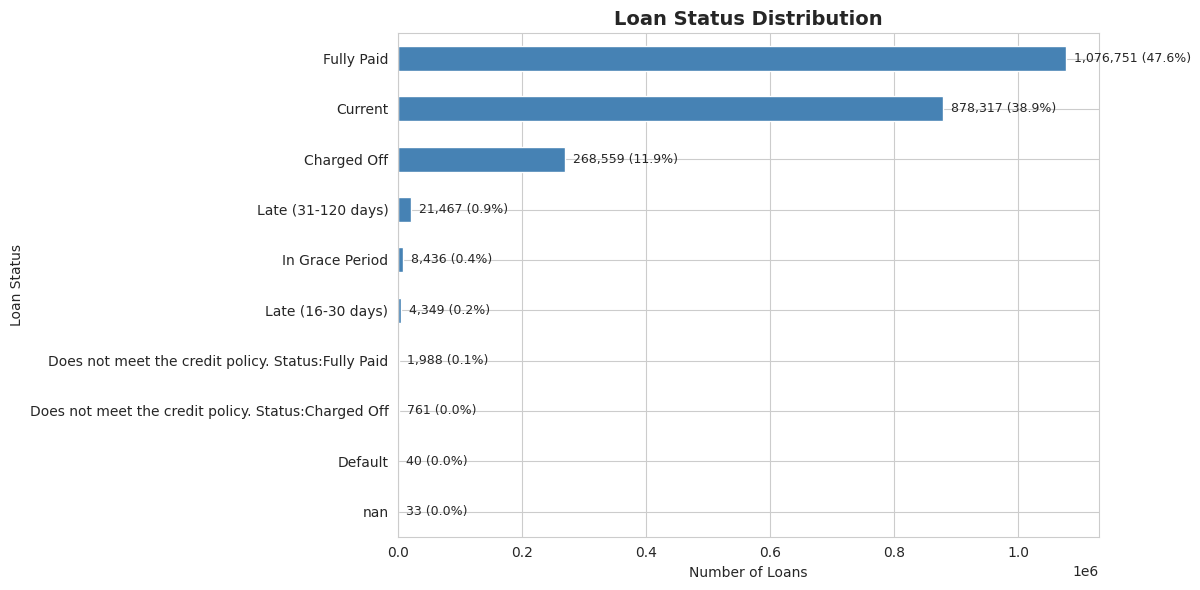

In [ ]:
plt.figure(figsize=(12, 6))

# Bar plot
status_counts.plot(kind='barh', color='steelblue')

plt.title('Loan Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Loans')
plt.ylabel('Loan Status')
plt.gca().invert_yaxis()

for i, (count, pct) in enumerate(zip(status_counts.values, status_pct.values)):
    plt.text(count, i, f'  {count:,} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
df['issue_year'] = df['issue_d'].dt.year

# Cross-tab: status × year
status_by_year = pd.crosstab(df['issue_year'],
                              df['loan_status'],
                              normalize='index') * 100

main_statuses = ['Fully Paid', 'Current', 'Charged Off', 'Default',
                  'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period']
existing_statuses = [s for s in main_statuses if s in status_by_year.columns]

print("loan_status % by issue year:\n")
print(status_by_year[existing_statuses].round(2))

loan_status % by issue year:

loan_status  Fully Paid  Current  Charged Off  Default  Late (31-120 days)  \
issue_year                                                                   
2007.0000       34.1600   0.0000       7.4600   0.0000              0.0000   
2008.0000       54.9500   0.0000      10.3200   0.0000              0.0000   
2009.0000       78.0500   0.0000      11.2500   0.0000              0.0000   
2010.0000       80.1500   0.0000      11.8600   0.0000              0.0000   
2011.0000       84.8200   0.0000      15.1800   0.0000              0.0000   
2012.0000       83.8000   0.0000      16.2000   0.0000              0.0000   
2013.0000       84.4000   0.0000      15.5900   0.0000              0.0000   
2014.0000       77.2200   5.0600      17.4700   0.0000              0.1400   
2015.0000       71.1800  10.2800      18.0000   0.0000              0.3200   
2016.0000       51.7600  30.8600      15.7100   0.0000              1.0500   
2017.0000       29.3400  59.0300  

In [ ]:
# Define default and non-default statuses
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)']
non_default_statuses = ['Fully Paid']

# Keep only loans with clear outcomes
clear_outcome_statuses = default_statuses + non_default_statuses
df_model = df[df['loan_status'].isin(clear_outcome_statuses)].copy()

# Create binary target
df_model['target'] = df_model['loan_status'].isin(default_statuses).astype(int)

print(f"Original dataset:    {len(df):,} rows")
print(f"After filtering:     {len(df_model):,} rows")
print(f"Dropped:             {len(df) - len(df_model):,} rows ({(1 - len(df_model)/len(df))*100:.1f}%)")

Original dataset:    2,260,701 rows
After filtering:     1,366,817 rows
Dropped:             893,884 rows (39.5%)


In [ ]:
target_counts = df_model['target'].value_counts().sort_index()
target_pct = df_model['target'].value_counts(normalize=True).sort_index() * 100

print("Target distribution:")
print(f"  0 (Non-default):  {target_counts[0]:>10,} ({target_pct[0]:.2f}%)")
print(f"  1 (Default):      {target_counts[1]:>10,} ({target_pct[1]:.2f}%)")
print(f"\nBad rate: {target_pct[1]:.2f}%")
print(f"Imbalance ratio (0:1): {target_counts[0]/target_counts[1]:.2f}")

Target distribution:
  0 (Non-default):   1,076,751 (78.78%)
  1 (Default):         290,066 (21.22%)

Bad rate: 21.22%
Imbalance ratio (0:1): 3.71


Bad rate by issue year:

 issue_year  loans  defaults  bad_rate
       2007    251        45   17.9283
       2008   1562       247   15.8131
       2009   4716       594   12.5954
       2010  11536      1487   12.8901
       2011  21721      3297   15.1789
       2012  53367      8644   16.1973
       2013 134807     21027   15.5979
       2014 223437     41496   18.5717
       2015 376905     77163   20.4728
       2016 297651     72798   24.4575
       2017 177325     47173   26.6026
       2018  63539     16095   25.3309


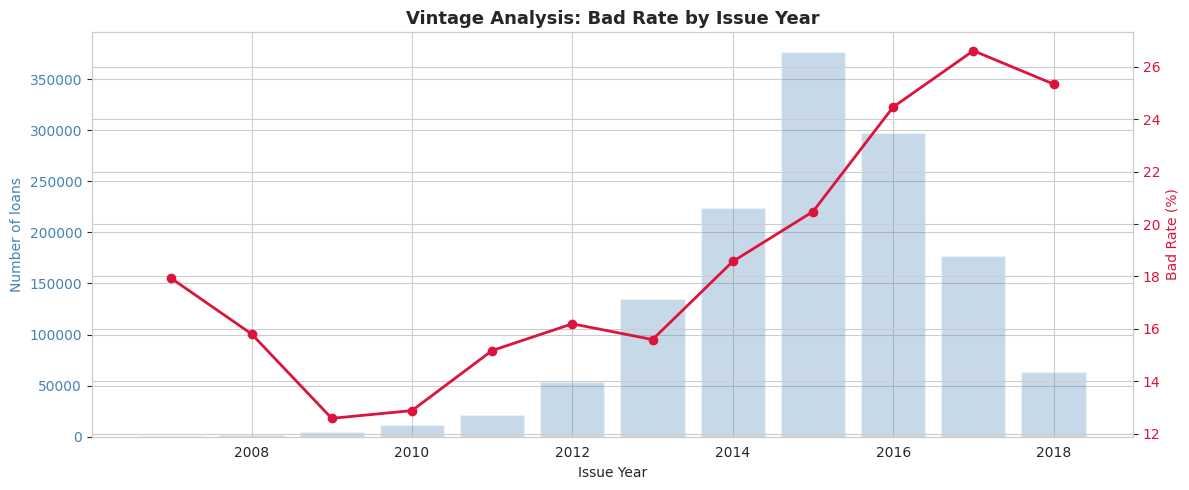

In [ ]:
# Bad rate by issue year
df_model['issue_year'] = df_model['issue_d'].dt.year

vintage = df_model.groupby('issue_year').agg(
    loans=('target', 'count'),
    defaults=('target', 'sum'),
    bad_rate=('target', 'mean')
).reset_index()
vintage['bad_rate'] = vintage['bad_rate'] * 100

print("Bad rate by issue year:\n")
print(vintage.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(vintage['issue_year'], vintage['loans'],
        alpha=0.3, color='steelblue', label='Number of loans')
ax1.set_xlabel('Issue Year')
ax1.set_ylabel('Number of loans', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(vintage['issue_year'], vintage['bad_rate'],
         color='crimson', marker='o', linewidth=2, label='Bad rate (%)')
ax2.set_ylabel('Bad Rate (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Vintage Analysis: Bad Rate by Issue Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
missing = pd.DataFrame({
    'missing_count': df_model.isnull().sum(),
    'missing_pct': df_model.isnull().mean() * 100,
    'dtype': df_model.dtypes.astype(str)
})
missing = missing.sort_values('missing_pct', ascending=False)

missing_only = missing[missing['missing_pct'] > 0]

print(f"Total columns: {len(df_model.columns)}")
print(f"Columns with missing values: {len(missing_only)}")
print(f"Columns with > 50% missing: {(missing['missing_pct'] > 50).sum()}")
print(f"Columns with > 90% missing: {(missing['missing_pct'] > 90).sum()}")

print(f"\nTop 30 columns by missing %:\n")
print(missing_only.head(30).round(2))

Total columns: 153
Columns with missing values: 105
Columns with > 50% missing: 58
Columns with > 90% missing: 39

Top 30 columns by missing %:

                                            missing_count  missing_pct  \
member_id                                         1366817     100.0000   
orig_projected_additional_accrued_interest        1361609      99.6200   
payment_plan_start_date                           1359438      99.4600   
hardship_status                                   1359438      99.4600   
hardship_start_date                               1359438      99.4600   
hardship_dpd                                      1359438      99.4600   
hardship_loan_status                              1359438      99.4600   
hardship_length                                   1359438      99.4600   
deferral_term                                     1359438      99.4600   
hardship_payoff_balance_amount                    1359438      99.4600   
hardship_last_payment_amount             

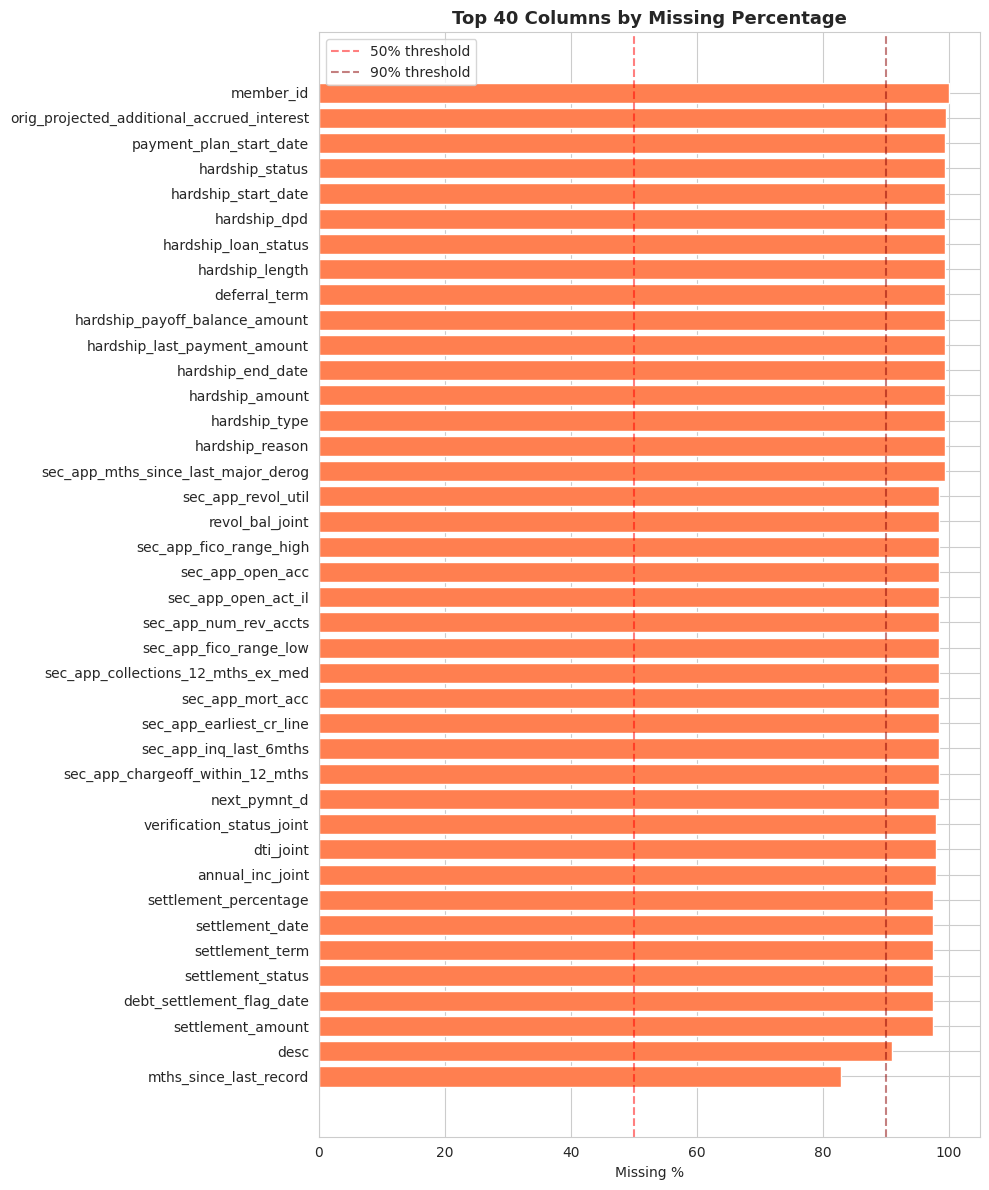

In [ ]:
top_missing = missing_only.head(40)

plt.figure(figsize=(10, 12))
plt.barh(range(len(top_missing)), top_missing['missing_pct'], color='coral')
plt.yticks(range(len(top_missing)), top_missing.index)
plt.xlabel('Missing %')
plt.title('Top 40 Columns by Missing Percentage', fontsize=13, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.axvline(x=90, color='darkred', linestyle='--', alpha=0.5, label='90% threshold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ===== Group 1: Data leakage (post-funding info) — must exclude from PD model =====
LEAKAGE_FEATURES = [
    # Payment information
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',

    # Outstanding balance
    'out_prncp', 'out_prncp_inv',

    # Last credit pull (after funding)
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # Hardship (post-funding)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',

    # Settlement (post-default)
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
]

# ===== Group 2: Metadata / IDs — not features =====
METADATA = [
    'id', 'member_id', 'url', 'desc',  # IDs and free text
    'loan_status',                      # this is the target, not a feature
    'pymnt_plan',                       # only set when payment plan applied
]

# ===== Group 3: Target =====
TARGET = 'target'

# ===== Group 4: Safe features (available at application time) =====
# = everything that is not in the 3 groups above
all_cols = set(df_model.columns)
safe_features = list(all_cols - set(LEAKAGE_FEATURES) - set(METADATA) - {TARGET})

print(f"Leakage features (drop):   {len(LEAKAGE_FEATURES)}")
print(f"Metadata (drop):           {len(METADATA)}")
print(f"Safe features (candidate): {len(safe_features)}")
print(f"Total:                     {len(LEAKAGE_FEATURES) + len(METADATA) + len(safe_features) + 1}")

Leakage features (drop):   37
Metadata (drop):           6
Safe features (candidate): 109
Total:                     153


In [ ]:
# Check missing % for safe features only
safe_missing = missing.loc[safe_features].sort_values('missing_pct', ascending=False)

# Filter to features with at least some missing values
safe_missing_only = safe_missing[safe_missing['missing_pct'] > 0]

print(f"Safe features with missing values: {len(safe_missing_only)}")
print(f"  > 90% missing: {(safe_missing['missing_pct'] > 90).sum()}")
print(f"  > 50% missing: {(safe_missing['missing_pct'] > 50).sum()}")
print(f"  > 30% missing: {(safe_missing['missing_pct'] > 30).sum()}")

print(f"\nTop 30 safe features by missing %:\n")
print(safe_missing_only.head(30).round(2))

Safe features with missing values: 80
  > 90% missing: 16
  > 50% missing: 35
  > 30% missing: 35

Top 30 safe features by missing %:

                                     missing_count  missing_pct    dtype
sec_app_mths_since_last_major_derog        1359341      99.4500  float64
sec_app_revol_util                         1346536      98.5200  float64
revol_bal_joint                            1346170      98.4900  float64
sec_app_chargeoff_within_12_mths           1346169      98.4900  float64
sec_app_fico_range_high                    1346169      98.4900  float64
sec_app_mort_acc                           1346169      98.4900  float64
sec_app_num_rev_accts                      1346169      98.4900  float64
sec_app_fico_range_low                     1346169      98.4900  float64
sec_app_earliest_cr_line                   1346169      98.4900   object
sec_app_inq_last_6mths                     1346169      98.4900  float64
sec_app_open_act_il                        1346169      98.490

In [ ]:
# Drop features with > 50% missing values
high_missing_features = safe_missing[safe_missing['missing_pct'] > 50].index.tolist()

print(f"Dropping {len(high_missing_features)} features with > 50% missing:\n")
for f in high_missing_features:
    print(f"  {f:<40} {safe_missing.loc[f, 'missing_pct']:.1f}% missing")

# Final feature set
final_features = [f for f in safe_features if f not in high_missing_features]

print(f"\n{'=' * 60}")
print(f"FINAL FEATURE SET: {len(final_features)} features")
print(f"{'=' * 60}")

Dropping 35 features with > 50% missing:

  sec_app_mths_since_last_major_derog      99.5% missing
  sec_app_revol_util                       98.5% missing
  revol_bal_joint                          98.5% missing
  sec_app_chargeoff_within_12_mths         98.5% missing
  sec_app_fico_range_high                  98.5% missing
  sec_app_mort_acc                         98.5% missing
  sec_app_num_rev_accts                    98.5% missing
  sec_app_fico_range_low                   98.5% missing
  sec_app_earliest_cr_line                 98.5% missing
  sec_app_inq_last_6mths                   98.5% missing
  sec_app_open_act_il                      98.5% missing
  sec_app_collections_12_mths_ex_med       98.5% missing
  sec_app_open_acc                         98.5% missing
  verification_status_joint                98.0% missing
  dti_joint                                98.0% missing
  annual_inc_joint                         98.0% missing
  mths_since_last_record                   83.

In [ ]:
# Build the cleaned modeling dataset (features + target only)
model_cols = final_features + [TARGET]
df_clean = df_model[model_cols].copy()

print(f"Modeling dataset shape: {df_clean.shape}")
print(f"Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Free memory by deleting the old DataFrame
del df_model
gc.collect()

print(f"\n✓ Cleaned up old DataFrame, freed memory")
print(f"\nFirst 5 rows:")
df_clean.head()

Modeling dataset shape: (1366817, 75)
Memory usage: 1736.0 MB

✓ Cleaned up old DataFrame, freed memory

First 5 rows:


,funded_amnt,num_bc_tl,issue_year,revol_util,policy_code,total_bc_limit,num_bc_sats,mths_since_recent_inq,annual_inc,delinq_2yrs,sub_grade,mths_since_recent_bc,num_sats,collections_12_mths_ex_med,num_accts_ever_120_pd,installment,initial_list_status,verification_status,pub_rec_bankruptcies,pub_rec,tot_hi_cred_lim,acc_open_past_24mths,total_bal_ex_mort,num_actv_rev_tl,num_tl_30dpd,bc_open_to_buy,tot_cur_bal,zip_code,num_op_rev_tl,loan_amnt,pct_tl_nvr_dlq,total_rev_hi_lim,int_rate,grade,issue_d,num_tl_90g_dpd_24m,addr_state,num_rev_tl_bal_gt_0,inq_last_6mths,total_il_high_credit_limit,bc_util,mo_sin_old_il_acct,fico_range_high,mort_acc,tax_liens,fico_range_low,mo_sin_rcnt_rev_tl_op,acc_now_delinq,tot_coll_amt,purpose,num_il_tl,num_tl_op_past_12m,num_rev_accts,emp_length,application_type,num_tl_120dpd_2m,delinq_amnt,term,emp_title,home_ownership,dti,percent_bc_gt_75,funded_amnt_inv,disbursement_method,mo_sin_old_rev_tl_op,title,mo_sin_rcnt_tl,total_acc,revol_bal,num_actv_bc_tl,earliest_cr_line,open_acc,avg_cur_bal,chargeoff_within_12_mths,target
0,3600.0000,5.0000,2015,29.7000,1.0000,2400.0000,2.0000,4.0000,55000.0000,0.0000,C4,4.0000,7.0000,0.0000,2.0000,123.0300,w,Not Verified,0.0000,0.0000,178050.0000,4.0000,7746.0000,4.0000,0.0000,1506.0000,144904.0000,190xx,4.0000,3600.0000,76.9000,9300.0000,13.9900,C,2015-12-01,0.0000,PA,4.0000,1.0000,13734.0000,37.2000,148.0000,679.0000,1.0000,0.0000,675.0000,3.0000,0.0000,722.0000,debt_consolidation,3.0000,3.0000,9.0000,10+ years,Individual,0.0000,0.0000,36 months,leadman,MORTGAGE,5.9100,0.0000,3600.0000,Cash,128.0000,Debt consolidation,3.0000,13.0000,2765.0000,2.0000,Aug-2003,7.0000,20701.0000,0.0000,0
1,24700.0000,17.0000,2015,19.2000,1.0000,79300.0000,13.0000,0.0000,65000.0000,1.0000,C1,2.0000,22.0000,0.0000,0.0000,820.2800,w,Not Verified,0.0000,0.0000,314017.0000,4.0000,39475.0000,5.0000,0.0000,57830.0000,204396.0000,577xx,20.0000,24700.0000,97.4000,111800.0000,11.9900,C,2015-12-01,0.0000,SD,5.0000,4.0000,24667.0000,27.1000,113.0000,719.0000,4.0000,0.0000,715.0000,2.0000,0.0000,0.0000,small_business,6.0000,2.0000,27.0000,10+ years,Individual,0.0000,0.0000,36 months,Engineer,MORTGAGE,16.0600,7.7000,24700.0000,Cash,192.0000,Business,2.0000,38.0000,21470.0000,5.0000,Dec-1999,22.0000,9733.0000,0.0000,0
2,20000.0000,4.0000,2015,56.2000,1.0000,6200.0000,2.0000,10.0000,63000.0000,0.0000,B4,101.0000,6.0000,0.0000,0.0000,432.6600,w,Not Verified,0.0000,0.0000,218418.0000,6.0000,18696.0000,3.0000,0.0000,2737.0000,189699.0000,605xx,4.0000,20000.0000,100.0000,14000.0000,10.7800,B,2015-12-01,0.0000,IL,3.0000,0.0000,14877.0000,55.9000,125.0000,699.0000,5.0000,0.0000,695.0000,14.0000,0.0000,0.0000,home_improvement,6.0000,0.0000,7.0000,10+ years,Joint App,0.0000,0.0000,60 months,truck driver,MORTGAGE,10.7800,50.0000,20000.0000,Cash,184.0000,NaN,14.0000,18.0000,7869.0000,2.0000,Aug-2000,6.0000,31617.0000,0.0000,0
4,10400.0000,9.0000,2015,64.5000,1.0000,20300.0000,5.0000,1.0000,104433.0000,1.0000,F1,4.0000,12.0000,0.0000,0.0000,289.9100,w,Source Verified,0.0000,0.0000,439570.0000,10.0000,95768.0000,6.0000,0.0000,4567.0000,331730.0000,174xx,7.0000,10400.0000,96.6000,34000.0000,22.4500,F,2015-12-01,0.0000,PA,6.0000,3.0000,88097.0000,77.5000,128.0000,699.0000,6.0000,0.0000,695.0000,4.0000,0.0000,0.0000,major_purchase,10.0000,4.0000,19.0000,3 years,Individual,0.0000,0.0000,60 months,Contract Specialist,MORTGAGE,25.3700,60.0000,10400.0000,Cash,210.0000,Major purchase,4.0000,35.0000,21929.0000,4.0000,Jun-1998,12.0000,27644.0000,0.0000,0
5,11950.0000,2.0000,2015,68.4000,1.0000,9400.0000,2.0000,NaN,34000.0000,0.0000,C3,36.0000,5.0000,0.0000,0.0000,405.1800,w,Source Verified,0.0000,0.0000,16900.0000,0.0000,12798.0000,3.0000,0.0000,844.0000,12798.0000,300xx,4.0000,11950.0000,100.0000,12900.0000,13.4400,C,2015-12-01,0.0000,GA,3.0000,0.0000,4000.0000,91.0000,338.0000,694.0000,0.0000,0.0000,690.0000,32.0000,0.0000,0.0000,debt_consolidation,2.0000,0.0000,4.0000,4 years,Individual,0.0000,0.0000,36 months,Veterinary Te

In [ ]:
# Identify feature types (excluding target)
features = [c for c in df_clean.columns if c != TARGET]

numeric_features = df_clean[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_clean[features].select_dtypes(include=['object']).columns.tolist()
datetime_features = df_clean[features].select_dtypes(include=['datetime64']).columns.tolist()

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Datetime features:    {len(datetime_features)}")
print(f"Total:                {len(numeric_features) + len(categorical_features) + len(datetime_features)}")

print(f"\nCategorical features:")
for c in categorical_features:
    print(f"  - {c}")

print(f"\nDatetime features:")
for c in datetime_features:
    print(f"  - {c}")

Numeric features:     57
Categorical features: 15
Datetime features:    1
Total:                73

Categorical features:
  - sub_grade
  - initial_list_status
  - verification_status
  - zip_code
  - grade
  - addr_state
  - purpose
  - emp_length
  - application_type
  - term
  - emp_title
  - home_ownership
  - disbursement_method
  - title
  - earliest_cr_line

Datetime features:
  - issue_d


In [ ]:
print("Categorical features — cardinality and sample values:\n")
print(f"{'Feature':<25} {'Unique':<10} {'Missing %':<12} Sample values")
print("=" * 100)

for col in categorical_features:
    n_unique = df_clean[col].nunique()
    missing_pct = df_clean[col].isnull().mean() * 100
    sample = df_clean[col].dropna().value_counts().head(3).index.tolist()
    print(f"{col:<25} {n_unique:<10,} {missing_pct:<12.2f} {sample}")

Categorical features — cardinality and sample values:

Feature                   Unique     Missing %    Sample values
sub_grade                 35         0.00         ['C1', 'B4', 'B5']
initial_list_status       2          0.00         ['w', 'f']
verification_status       3          0.00         ['Source Verified', 'Verified', 'Not Verified']
zip_code                  944        0.00         ['945xx', '750xx', '112xx']
grade                     7          0.00         ['B', 'C', 'A']
addr_state                51         0.00         ['CA', 'TX', 'NY']
purpose                   14         0.00         ['debt_consolidation', 'credit_card', 'home_improvement']
emp_length                11         5.88         ['10+ years', '2 years', '< 1 year']
application_type          2          0.00         ['Individual', 'Joint App']
term                      2          0.00         [' 36 months', ' 60 months']
emp_title                 381,808    6.42         ['Teacher', 'Manager', 'Owner']
home_o

In [ ]:
# Statistics for numeric features
numeric_stats = df_clean[numeric_features].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
numeric_stats['missing_pct'] = df_clean[numeric_features].isnull().mean() * 100
numeric_stats['n_unique'] = df_clean[numeric_features].nunique()

# Format display
pd.set_option('display.max_rows', 100)
print(f"Numeric features — descriptive statistics:\n")
print(numeric_stats[['count', 'mean', 'std', 'min', '1%', '50%', '99%', 'max',
                     'missing_pct', 'n_unique']].round(2))

Numeric features — descriptive statistics:

                                  count        mean         std      min  \
funded_amnt                1366817.0000  14451.3700   8734.6200 500.0000   
num_bc_tl                  1299290.0000      8.0900      4.8000   0.0000   
revol_util                 1365933.0000     51.7700     24.5300   0.0000   
policy_code                1366817.0000      1.0000      0.0000   1.0000   
total_bc_limit             1319536.0000  21616.5700  21548.1300   0.0000   
num_bc_sats                1310976.0000      4.7400      2.9600   0.0000   
mths_since_recent_inq      1190992.0000      6.7100      5.8500   0.0000   
annual_inc                 1366817.0000  76259.7900  70313.6200   0.0000   
delinq_2yrs                1366817.0000      0.3200      0.8800   0.0000   
mths_since_recent_bc       1306300.0000     23.7800     30.7300   0.0000   
num_sats                   1310976.0000     11.6400      5.4900   0.0000   
collections_12_mths_ex_med 1366761.0000     

In [ ]:
cleaning_plan = []

# 1. Features with low variance (near-constant — likely useless)
for col in numeric_features:
    if df_clean[col].nunique() <= 1:
        cleaning_plan.append((col, 'DROP', 'constant value'))

# 2. High-cardinality categorical (need special handling)
for col in categorical_features:
    n_unique = df_clean[col].nunique()
    if n_unique > 1000:
        cleaning_plan.append((col, 'HIGH_CARDINALITY', f'{n_unique:,} unique values'))

# 3. String features needing conversion
string_conversion = {
    'term': 'Convert " 36 months" → 36',
    'emp_length': 'Convert "10+ years" → 10',
    'earliest_cr_line': 'Convert date string → months_since',
}
for col, action in string_conversion.items():
    if col in df_clean.columns:
        cleaning_plan.append((col, 'CONVERT', action))

# 4. Features with remaining missing values
remaining_missing = df_clean[features].isnull().mean() * 100
features_with_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
for col, pct in features_with_missing.items():
    cleaning_plan.append((col, 'IMPUTE', f'{pct:.1f}% missing'))

# Display plan
print(f"Cleaning plan: {len(cleaning_plan)} items\n")
print(f"{'Feature':<30} {'Action':<20} Detail")
print("=" * 90)
for col, action, detail in cleaning_plan:
    print(f"{col:<30} {action:<20} {detail}")

Cleaning plan: 51 items

Feature                        Action               Detail
policy_code                    DROP                 constant value
emp_title                      HIGH_CARDINALITY     381,808 unique values
title                          HIGH_CARDINALITY     61,683 unique values
term                           CONVERT              Convert " 36 months" → 36
emp_length                     CONVERT              Convert "10+ years" → 10
earliest_cr_line               CONVERT              Convert date string → months_since
mths_since_recent_inq          IMPUTE               12.9% missing
num_tl_120dpd_2m               IMPUTE               8.7% missing
mo_sin_old_il_acct             IMPUTE               7.8% missing
emp_title                      IMPUTE               6.4% missing
emp_length                     IMPUTE               5.9% missing
pct_tl_nvr_dlq                 IMPUTE               5.0% missing
avg_cur_bal                    IMPUTE               4.9% missing
num_

In [ ]:
# Check correlation between funded_amnt and funded_amnt_inv first
corr = df_clean['funded_amnt'].corr(df_clean['funded_amnt_inv'])
print(f"Correlation funded_amnt vs funded_amnt_inv: {corr:.4f}")

# Columns to drop with reasoning
columns_to_drop = {
    'policy_code': 'Constant value (always 1)',
    'emp_title': 'High cardinality free text (381k unique)',
    'title': 'High cardinality free text (61k unique), redundant with purpose',
    'zip_code': 'High cardinality (944 unique), redundant with addr_state',
    'funded_amnt_inv': 'Nearly identical to funded_amnt',
}

print(f"\nDropping {len(columns_to_drop)} columns:")
for col, reason in columns_to_drop.items():
    print(f"  - {col:<20} | {reason}")

df_clean = df_clean.drop(columns=list(columns_to_drop.keys()))
print(f"\nShape after dropping: {df_clean.shape}")

Correlation funded_amnt vs funded_amnt_inv: 0.9991

Dropping 5 columns:
  - policy_code          | Constant value (always 1)
  - emp_title            | High cardinality free text (381k unique)
  - title                | High cardinality free text (61k unique), redundant with purpose
  - zip_code             | High cardinality (944 unique), redundant with addr_state
  - funded_amnt_inv      | Nearly identical to funded_amnt

Shape after dropping: (1366817, 70)


In [ ]:
# Convert term: " 36 months" → 36
df_clean['term'] = df_clean['term'].str.extract(r'(\d+)').astype(int)

# Convert emp_length: "10+ years" → 10, "< 1 year" → 0, "n years" → n
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
}
df_clean['emp_length'] = df_clean['emp_length'].map(emp_length_map)

# Verify
print("term — unique values:")
print(df_clean['term'].value_counts().sort_index())

print("\nemp_length — unique values:")
print(df_clean['emp_length'].value_counts(dropna=False).sort_index())

term — unique values:
term
36    1033242
60     333575
Name: count, dtype: int64

emp_length — unique values:
emp_length
0.0000     110094
1.0000      89937
2.0000     123714
3.0000     109396
4.0000      81971
5.0000      85473
6.0000      63654
7.0000      60395
8.0000      61459
9.0000      51575
10.0000    448782
NaN         80367
Name: count, dtype: int64


In [ ]:
# Convert earliest_cr_line from "Aug-2003" to datetime
df_clean['earliest_cr_line'] = pd.to_datetime(
    df_clean['earliest_cr_line'],
    format='%b-%Y',
    errors='coerce'
)

# Create credit_history_months = months between earliest_cr_line and issue_d
df_clean['credit_history_months'] = (
    (df_clean['issue_d'] - df_clean['earliest_cr_line']).dt.days / 30.44
).round().astype('Int64')  # Int64 supports NaN

# Drop original date columns (we have what we need)
df_clean = df_clean.drop(columns=['earliest_cr_line', 'issue_d'])

# Verify
print("credit_history_months statistics:")
print(df_clean['credit_history_months'].describe().round(2))

print(f"\nMissing: {df_clean['credit_history_months'].isnull().sum()}")
print(f"Negative values (data error): {(df_clean['credit_history_months'] < 0).sum()}")

credit_history_months statistics:
count   1366817.0000
mean        195.0400
std          90.1400
min          36.0000
25%         134.0000
50%         177.0000
75%         240.0000
max         999.0000
Name: credit_history_months, dtype: Float64

Missing: 0
Negative values (data error): 0


In [ ]:
# 1. Replace placeholder values with NaN
placeholder_map = {
    'dti': [999, -1],                   # Invalid DTI values
    'mo_sin_old_il_acct': [999],        # Placeholder for missing
    'tot_hi_cred_lim': [9999999],
    'total_rev_hi_lim': [9999999],
}

print("Replacing placeholder values with NaN:\n")
for col, placeholders in placeholder_map.items():
    if col in df_clean.columns:
        before_missing = df_clean[col].isnull().sum()
        for ph in placeholders:
            df_clean.loc[df_clean[col] == ph, col] = np.nan
        after_missing = df_clean[col].isnull().sum()
        print(f"  {col:<25} | {before_missing} → {after_missing} missing "
              f"(+{after_missing - before_missing} placeholders replaced)")

# 2. Cap revol_util and bc_util at 200 (anything above is likely data error)
cap_features = {
    'revol_util': 200,
    'bc_util': 200,
    'percent_bc_gt_75': 100,
}

print("\nCapping outlier values:\n")
for col, cap in cap_features.items():
    if col in df_clean.columns:
        before = (df_clean[col] > cap).sum()
        df_clean[col] = df_clean[col].clip(upper=cap)
        print(f"  {col:<25} | Capped at {cap}, affected {before} rows")

# 3. Log-transform annual_inc to handle skewness (top 1% reaches $250k, max $10M)
df_clean['annual_inc_log'] = np.log1p(df_clean['annual_inc'])

print(f"\nCreated annual_inc_log (log1p transformed)")
print(f"  annual_inc: min={df_clean['annual_inc'].min():,.0f}, "
      f"max={df_clean['annual_inc'].max():,.0f}")
print(f"  annual_inc_log: min={df_clean['annual_inc_log'].min():.2f}, "
      f"max={df_clean['annual_inc_log'].max():.2f}")

Replacing placeholder values with NaN:

  dti                       | 398 → 441 missing (+43 placeholders replaced)
  mo_sin_old_il_acct        | 106360 → 106361 missing (+1 placeholders replaced)
  tot_hi_cred_lim           | 67527 → 67539 missing (+12 placeholders replaced)
  total_rev_hi_lim          | 67527 → 67530 missing (+3 placeholders replaced)

Capping outlier values:

  revol_util                | Capped at 200, affected 2 rows
  bc_util                   | Capped at 200, affected 10 rows
  percent_bc_gt_75          | Capped at 100, affected 0 rows

Created annual_inc_log (log1p transformed)
  annual_inc: min=0, max=10,999,200
  annual_inc_log: min=0.00, max=16.21


In [ ]:
# 1. FICO average — combine fico_range_low and fico_range_high
df_clean['fico_avg'] = (df_clean['fico_range_low'] + df_clean['fico_range_high']) / 2

# 2. Loan to income ratio (avoid division by zero)
df_clean['loan_to_income'] = df_clean['loan_amnt'] / (df_clean['annual_inc'] + 1)

# 3. Installment to income ratio (annual)
df_clean['installment_to_income'] = (df_clean['installment'] * 12) / (df_clean['annual_inc'] + 1)

# 4. Cap credit_history_months at 600 (50 years) to handle data errors
n_capped = (df_clean['credit_history_months'] > 600).sum()
df_clean['credit_history_months'] = df_clean['credit_history_months'].clip(upper=600)
print(f"Capped credit_history_months at 600 months: {n_capped} rows affected\n")

# Verify new features
print("New features statistics:")
print(df_clean[['fico_avg', 'loan_to_income', 'installment_to_income',
                'credit_history_months']].describe().round(3))

Capped credit_history_months at 600 months: 1284 rows affected

New features statistics:
          fico_avg  loan_to_income  installment_to_income  \
count 1366817.0000    1366817.0000           1366817.0000   
mean      698.1250          5.2160                 1.8410   
std        31.8160        344.4830               120.9170   
min       627.0000          0.0000                 0.0000   
25%       672.0000          0.1250                 0.0460   
50%       692.0000          0.2000                 0.0720   
75%       712.0000          0.2920                 0.1060   
max       847.5000      40000.0000             17602.2000   

       credit_history_months  
count           1366817.0000  
mean                195.0030  
std                  89.9520  
min                  36.0000  
25%                 134.0000  
50%                 177.0000  
75%                 240.0000  
max                 600.0000  


In [ ]:
# Check missing state BEFORE imputation
missing_before = df_clean.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print(f"Columns with missing values BEFORE imputation: {len(missing_before)}")
print(missing_before.head(15))

# Re-identify column types (after dropping/adding columns)
features = [c for c in df_clean.columns if c != TARGET]
numeric_features = df_clean[features].select_dtypes(include=['int64', 'float64', 'Int64']).columns.tolist()
categorical_features = df_clean[features].select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Impute numeric with median
for col in numeric_features:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# Impute categorical with mode
for col in categorical_features:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode().iloc[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

# Verify
missing_after = df_clean.isnull().sum().sum()
print(f"\nTotal missing values AFTER imputation: {missing_after}")
assert missing_after == 0, "Some missing values remain"
print("✓ All missing values imputed")

Columns with missing values BEFORE imputation: 42
mths_since_recent_inq    175825
num_tl_120dpd_2m         118761
mo_sin_old_il_acct       106361
emp_length                80367
pct_tl_nvr_dlq            67681
avg_cur_bal               67550
tot_hi_cred_lim           67539
total_rev_hi_lim          67530
mo_sin_rcnt_rev_tl_op     67528
mo_sin_old_rev_tl_op      67528
num_rev_accts             67528
num_actv_bc_tl            67527
num_il_tl                 67527
tot_coll_amt              67527
num_tl_op_past_12m        67527
dtype: int64

Numeric features: 62
Categorical features: 9

Total missing values AFTER imputation: 0
✓ All missing values imputed


In [ ]:
# ----- 1. Ordinal encoding for grade and sub_grade -----
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['grade'] = df_clean['grade'].map(grade_map)

# sub_grade: A1=1, A2=2, ..., G5=35
sub_grades = sorted(df_clean['sub_grade'].unique())  # ['A1', 'A2', ..., 'G5']
sub_grade_map = {sg: i+1 for i, sg in enumerate(sub_grades)}
df_clean['sub_grade'] = df_clean['sub_grade'].map(sub_grade_map)

print(f"Ordinal encoded: grade ({df_clean['grade'].nunique()} levels), "
      f"sub_grade ({df_clean['sub_grade'].nunique()} levels)")

# ----- 2. One-hot encoding for nominal categoricals -----
nominal_cols = ['home_ownership', 'purpose', 'verification_status',
                'application_type', 'initial_list_status', 'disbursement_method',
                'addr_state']

print(f"\nBefore one-hot: {df_clean.shape}")
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)
print(f"After one-hot:  {df_clean.shape}")

# Verify no object columns remain (except target check)
remaining_objects = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining object columns: {remaining_objects}")
assert len(remaining_objects) == 0, f"Object columns still exist: {remaining_objects}"
print("✓ All categoricals encoded")

Ordinal encoded: grade (7 levels), sub_grade (35 levels)

Before one-hot: (1366817, 73)
After one-hot:  (1366817, 139)

Remaining object columns: []
✓ All categoricals encoded


In [ ]:
# Check how many rows have annual_inc = 0 (root cause of the outliers)
zero_income = (df_clean['annual_inc'] == 0).sum()
print(f"Rows with annual_inc = 0: {zero_income:,}")

# Cap ratio features at 99th percentile
ratio_features = ['loan_to_income', 'installment_to_income']

print("\nCapping ratio features at 99th percentile:\n")
for col in ratio_features:
    p99 = df_clean[col].quantile(0.99)
    n_capped = (df_clean[col] > p99).sum()
    df_clean[col] = df_clean[col].clip(upper=p99)
    print(f"  {col:<25} cap = {p99:.4f}, capped {n_capped:,} rows")

# Verify
print("\nAfter capping:")
print(df_clean[ratio_features].describe().round(4))

Rows with annual_inc = 0: 384

Capping ratio features at 99th percentile:

  loan_to_income            cap = 0.5000, capped 13,628 rows
  installment_to_income     cap = 0.2018, capped 13,669 rows

After capping:
       loan_to_income  installment_to_income
count    1366817.0000           1366817.0000
mean           0.2139                 0.0790
std            0.1142                 0.0427
min            0.0002                 0.0001
25%            0.1250                 0.0464
50%            0.2000                 0.0723
75%            0.2917                 0.1056
max            0.5000                 0.2018


In [ ]:
from sklearn.model_selection import train_test_split

# Define split based on issue_year
TRAIN_YEAR_MAX = 2016

train_mask = df_clean['issue_year'] <= TRAIN_YEAR_MAX
test_mask = df_clean['issue_year'] > TRAIN_YEAR_MAX

# Separate features and target
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# Summary
print("=" * 60)
print("TRAIN/TEST SPLIT SUMMARY")
print("=" * 60)
print(f"Train set: issue_year ≤ {TRAIN_YEAR_MAX}")
print(f"  Rows:     {len(X_train):,}")
print(f"  Features: {X_train.shape[1]}")
print(f"  Bad rate: {y_train.mean()*100:.2f}%")
print(f"  Year range: {X_train['issue_year'].min()} – {X_train['issue_year'].max()}")

print(f"\nTest set: issue_year > {TRAIN_YEAR_MAX}")
print(f"  Rows:     {len(X_test):,}")
print(f"  Features: {X_test.shape[1]}")
print(f"  Bad rate: {y_test.mean()*100:.2f}%")
print(f"  Year range: {X_test['issue_year'].min()} – {X_test['issue_year'].max()}")

print(f"\nTotal rows: {len(X_train) + len(X_test):,}")
print(f"Train ratio: {len(X_train) / (len(X_train) + len(X_test)) * 100:.1f}%")

# Free original DataFrame
del df_clean, X
gc.collect()
print("\n✓ Train/test split complete")

TRAIN/TEST SPLIT SUMMARY
Train set: issue_year ≤ 2016
  Rows:     1,125,953
  Features: 138
  Bad rate: 20.14%
  Year range: 2007 – 2016

Test set: issue_year > 2016
  Rows:     240,864
  Features: 138
  Bad rate: 26.27%
  Year range: 2017 – 2018

Total rows: 1,366,817
Train ratio: 82.4%

✓ Train/test split complete


In [ ]:
# Save processed data to Drive
print("Saving processed data to Drive...\n")

X_train.to_parquet(f'{DRIVE_PATH}/X_train.parquet')
print(f"✓ Saved X_train.parquet ({X_train.shape})")

y_train.to_frame().to_parquet(f'{DRIVE_PATH}/y_train.parquet')
print(f"✓ Saved y_train.parquet ({len(y_train):,} rows)")

X_test.to_parquet(f'{DRIVE_PATH}/X_test.parquet')
print(f"✓ Saved X_test.parquet ({X_test.shape})")

y_test.to_frame().to_parquet(f'{DRIVE_PATH}/y_test.parquet')
print(f"✓ Saved y_test.parquet ({len(y_test):,} rows)")

# Check file sizes
import os
print("\nFile sizes:")
for fname in ['X_train.parquet', 'y_train.parquet', 'X_test.parquet', 'y_test.parquet']:
    size_mb = os.path.getsize(f'{DRIVE_PATH}/{fname}') / 1024**2
    print(f"  {fname:<25} {size_mb:.1f} MB")

Saving processed data to Drive...

✓ Saved X_train.parquet ((1125953, 138))
✓ Saved y_train.parquet (1,125,953 rows)
✓ Saved X_test.parquet ((240864, 138))
✓ Saved y_test.parquet (240,864 rows)

File sizes:
  X_train.parquet           97.2 MB
  y_train.parquet           4.9 MB
  X_test.parquet            22.0 MB
  y_test.parquet            1.2 MB
